# Regresión Lineal Múltiple y Selección de Características: Predicción de Calificaciones Escolares

Arturo Vargas Espinosa

## Introducción

En este reporte se construye un modelo de regresión lineal múltiple para predecir la calificación final (**G3**) de un grupo de estudiantes, a partir de información demográfica, de hábitos de estudio y de calificaciones parciales. A diferencia de un conjunto de datos "de laboratorio", esta base de datos presenta varios de los retos típicos de un problema real: variables cualitativas que deben codificarse, valores potencialmente atípicos, y variables que podrían estar midiendo información redundante entre sí (colinealidad).

El objetivo no es solo entrenar un modelo que prediga bien, sino documentar y justificar cada decisión tomada durante la limpieza, el análisis de relaciones entre variables y la selección de características, de forma que el proceso completo sea reproducible y quede claro por qué se llegó al modelo final.

Para este análisis se usará el archivo **calificaciones_estudiantes.csv**, un subconjunto de 10 variables del *Student Performance Data Set* de Cortez y Silva (2008), que originalmente contiene 33 variables recolectadas de estudiantes de matemáticas de dos escuelas secundarias portuguesas (Cortez & Silva, 2008). El detalle de cada variable se revisa en la sección de Exploración de los Datos.

## Metodología


Este estudio combina tres bloques de teoría: **regresión lineal** (simple y múltiple), **solución de problemas de datos reales**  y **selección de características** (selección de subconjuntos y regularización). A continuación se explica cada uno, y cómo se aplica específicamente en este estudio para predecir `G3`.

El orden en que se aplican estos bloques no es arbitrario: primero se entiende y limpia el dato (para no construir un modelo sobre información corrupta), después se separan los datos de entrenamiento y prueba (para poder medir honestamente qué tan bien generaliza el modelo), y solo después de esa separación se analiza la colinealidad y se seleccionan las características ,usando exclusivamente el subconjunto de entrenamiento, precisamente para no incurrir en fuga de datos. Al final, se entrena el modelo definitivo y se evalúa en ambos subconjuntos.

### Tipos de variables

En este análisis trabajamos con dos tipos de variable:

Tabla 1. Tipos de Variables

| Tipo de variable | ¿Qué es? | Ejemplo |
|---|---|---|
| Cuantitativa | Numérica; representa una cantidad y admite operaciones aritméticas (sumar, promediar, etc.) | Edad, ingreso, número de faltas |
| Cualitativa | Categórica; describe una cualidad, clase o grupo, no una cantidad | Escuela, sexo, color de ojos |

El tipo de una variable importa porque un modelo de regresión lineal solo sabe multiplicar y sumar números: si una variable cualitativa se usara tal cual (por ejemplo, asignándole arbitrariamente 0 y 1 a "GP" y "MS"), el modelo asumiría una relación numérica entre las categorías que en realidad no existe. Por eso las variables cualitativas requieren un tratamiento distinto antes de poder usarse en el modelo.


### De la regresión lineal simple a la regresión lineal múltiple

La **regresión lineal simple** modela la relación entre una sola variable explicativa $X$ y una variable de respuesta $Y$ como una línea recta:

$$Y = \beta_0 + \beta_1 X + \varepsilon$$

Los coeficientes se estiman por mínimos cuadrados: se busca la recta que minimiza $RSS = \sum (y_i - \hat{y}_i)^2$. $\beta_1$ se interpreta como "cuánto cambia $Y$, en promedio, por cada unidad que cambia $X$". Para saber si esa relación es real o podría deberse al azar, se calcula el estadístico $t = \beta_1 / SE(\beta_1)$ y su *p-value*.

(Ecuación hecha con Claude)

Casi ningún fenómeno real depende de una sola variable, así que la **regresión lineal múltiple** generaliza el modelo a $p$ variables explicativas:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p + \varepsilon$$
(Ecuación hecha con Claude)

La diferencia clave: ahora cada $\beta_i$ mide el efecto de $X_i$ sobre $Y$ **controlando por el resto de las variables**. Esto importa porque dos variables pueden parecer relacionadas con $Y$ en un modelo simple, pero dejar de estarlo (o hasta cambiar de signo) en un modelo múltiple, si en realidad ambas están relacionadas entre sí.

Para evaluar un modelo múltiple se usan tres cosas adicionales:

- **F-statistic y su p-value**: prueban si el modelo completo es mejor que no usar ningún predictor. Es la primera pregunta antes de interpretar coeficientes individuales.
- **R² ajustada, en vez de R² normal**: la R² normal siempre sube (o se mantiene) al agregar cualquier variable, aporte o no información real, así que no sirve para comparar modelos con distinta cantidad de variables. La R² ajustada penaliza la cantidad de variables usadas.
- **p-values individuales por variable**, que deben interpretarse con cautela cuando hay variables correlacionadas entre sí (ver Colinealidad).

En este estudio se parte de un modelo múltiple con las 9 variables explicativas disponibles como punto de referencia, y después se reduce mediante selección de características, comparando siempre con R² ajustada, no con R² simple.

### Solución de problemas, selección de características y evaluación

**Problemas típicos de datos reales y su solución:**
- **Variables cualitativas** → codificación *dummy*
- **Huecos** → eliminar (casos extremos) o imputar (media/mediana/moda, KNN, regresión)
- **Valores atípicos** → detectar con método de Tukey ($Q1-1.5\cdot IQR$, $Q3+1.5\cdot IQR$), pero investigar el contexto antes de eliminar
- **Colinealidad** → revisar matriz de correlación (*heatmap*); eliminar una variable solo si no aporta información marginal

**Selección de características:** una vez limpios los datos, no siempre conviene usar todas las variables (más riesgo de sobreajuste, menos interpretabilidad). Dos familias de métodos:
- **Selección de subconjuntos**: exhaustiva, o incremental (hacia adelante / hacia atrás)
- **Regularización** (Lasso): penaliza la magnitud de los coeficientes, puede llevarlos a cero

Se compara con **R² ajustada** (no R² normal, que siempre sube al agregar variables).

**Evaluación y fuga de datos:** el modelo se evalúa con RSE y R² en entrenamiento y prueba. Para que esa evaluación sea honesta, la división train/prueba se hace **antes** de analizar colinealidad o seleccionar variables, y ambos procesos usan solo el subconjunto de entrenamiento — de lo contrario hay fuga de datos y el desempeño en prueba queda inflado.

## Exploración de los Datos

Empezamos importando la libreria de pandas, numpy y matplotlib al igual usando 'read_csv' para leer el csv de 'calificaciones_estudiantes.csv'

Igualmente se imprime las primeras 15 tuplas usando df.head(15)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv('Datos/calificaciones_estudiantes.csv')

print(df.head(15))

   Escuela Sexo  Edad  HorasDeEstudio  Reprobadas Internet  Faltas  G1  G2  G3
0       GP    F    18               2           0       no       6   5   6   6
1       GP    F    17               2           0      yes       4   5   5   6
2       GP    F    15               2           3      yes      10   7   8  10
3       GP    F    15               3           0      yes       2  15  14  15
4       GP    F    16               2           0       no       4   6  10  10
5       GP    M    16               2           0      yes      10  15  15  15
6       GP    M    16               2           0      yes       0  12  12  11
7       GP    F    17               2           0       no       6   6   5   6
8       GP    M    15               2           0      yes       0  16  18  19
9       GP    M    15               2           0      yes       0  14  15  15
10      GP    F    15               2           0      yes       0  10   8   9
11      GP    F    15               3           0   

* Vamos a usar 'df.shape' para ver cual es la cantidad de observaciones que tenemos en el dataset, en lo que podemos observar que tenemos 395 observaciones a contraste de las 10 variables.
* También se utilizo '.info' para rechecar que las variables si sean la distinción entre cualitativa y cuantitativa
* Podemos ver que 7 son de una naturalez int y las otras son object, las cuales algunas las podremos convertir usando one-hot encoding ya despues

In [2]:
print(df.shape)

print(df.info())

(395, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Escuela         395 non-null    object
 1   Sexo            395 non-null    object
 2   Edad            395 non-null    int64 
 3   HorasDeEstudio  395 non-null    int64 
 4   Reprobadas      395 non-null    int64 
 5   Internet        395 non-null    object
 6   Faltas          395 non-null    int64 
 7   G1              395 non-null    int64 
 8   G2              395 non-null    int64 
 9   G3              395 non-null    int64 
dtypes: int64(7), object(3)
memory usage: 31.0+ KB
None


In [3]:
#Ver tipos de escuelas
print(df['Escuela'].unique())


['GP' 'MS']


In [4]:
print(df.describe())

             Edad  HorasDeEstudio  Reprobadas      Faltas          G1  \
count  395.000000      395.000000  395.000000  395.000000  395.000000   
mean    16.696203        2.035443    0.334177    5.708861   10.908861   
std      1.276043        0.839240    0.743651    8.003096    3.319195   
min     15.000000        1.000000    0.000000    0.000000    3.000000   
25%     16.000000        1.000000    0.000000    0.000000    8.000000   
50%     17.000000        2.000000    0.000000    4.000000   11.000000   
75%     18.000000        2.000000    0.000000    8.000000   13.000000   
max     22.000000        4.000000    3.000000   75.000000   19.000000   

               G2          G3  
count  395.000000  395.000000  
mean    10.713924   10.415190  
std      3.761505    4.581443  
min      0.000000    0.000000  
25%      9.000000    8.000000  
50%     11.000000   11.000000  
75%     13.000000   14.000000  
max     19.000000   20.000000  


Con esta información sobre la escuela, ya tenemos la información para hacer una tabla donde podemos describir de que consiste el dataframe

`Edad` va de 15 a 22 años (promedio de 16.7); `Faltas` va de 0 a 75, con una distribución muy sesgada (75% de los estudiantes tiene 8 faltas o menos, pero el máximo llega a 75); y `G1`, `G2` y `G3` se mueven en una escala de 0 a 20 puntos, con `G3` (la variable de respuesta) teniendo un promedio de 10.4.

Tabla 2. Descripción de variables de calificaciones_estudiantes.csv

| Variable | Tipo | Descripción |
|---|---|---|
| Escuela | Cualitativa | Escuela del estudiante: GP (Gabriel Pereira) o MS (Mousinho da Silveira) |
| Sexo | Cualitativa | F (femenino) o M (masculino) |
| Edad | Cuantitativa  | Edad del estudiante, en años (15 a 22) |
| HorasDeEstudio | Cualitativa | Tiempo semanal de estudio, en 4 categorías ordenadas: 1 (menos de 2h), 2 (2 a 5h), 3 (5 a 10h), 4 (más de 10h) |
| Reprobadas | Cuantitativa  | Cantidad de materias reprobadas previamente (0 a 3, donde 3 agrupa "3 o más") |
| Internet | Cualitativa | Si el estudiante cuenta (yes) o no (no) con acceso a internet en casa |
| Faltas | Cuantitativa  | Cantidad de faltas registradas en el curso |
| G1 | Cuantitativa  | Calificación del primer periodo, escala de 0 a 20 |
| G2 | Cuantitativa  | Calificación del segundo periodo, escala de 0 a 20 |
| G3 | Cuantitativa | Calificación final, escala de 0 a 20 (variable de respuesta) |

Podemos ver que hay variables que podemos convertir a numericas como Escuela, Sexo e Internet ya que son variables que ahorita estan en strings pero con algun tipo de encoding se pueden pasar a numericas

# **Preparación y Limpieza de Datos**

## Huecos

Ya en la exploración de los datos vimos que no había ningun nulo pero podemos rechecarlo con print(`df.info()`)

In [5]:

print(df.isnull().sum())

df.describe()

Escuela           0
Sexo              0
Edad              0
HorasDeEstudio    0
Reprobadas        0
Internet          0
Faltas            0
G1                0
G2                0
G3                0
dtype: int64


,Edad,HorasDeEstudio,Reprobadas,Faltas,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.035443,0.334177,5.708861,10.908861,10.713924,10.415190
std,1.276043,0.839240,0.743651,8.003096,3.319195,3.761505,4.581443
min,15.000000,1.000000,0.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,1.000000,0.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,2.000000,0.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,2.000000,0.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,3.000000,75.000000,19.000000,19.000000,20.000000


No se encontró ningún valor nulo, y los rangos de todas las variables numéricas son consistentes menos el de faltas. Por lo tanto, no fue necesario rellenar huecos, pero si se va a tener que limpiar esos datos de Faltas que son mayores a 10, para no darle un sesgo

## Valores cualitativos a encoding

Generamos las variables dummy para las tres variables cualitativas nominales:

- `pd.get_dummies(..., drop_first=True)` convierte cada variable categórica en su(s) columna(s) dummy, quedándose con $l-1$ columnas (la categoría restante queda representada implícitamente cuando todas las dummies valen 0)
- `.astype(int)` convierte el resultado de `True`/`False` a `1`/`0`
- Se renombra cada columna dummy generada (`.columns = [...]`) para que el nombre sea descriptivo en vez del valor original de la categoría (por ejemplo, `MS` en vez de "Mousinho da Silveira")
- `pd.concat(...)` agrega las tres nuevas columnas dummy al data frame original
- `df.drop(columns=[...])` elimina las tres variables originales (`Escuela`, `Sexo`, `Internet`), ya que su información quedó representada en las dummies
- `df.head()` imprime las primeras observaciones para confirmar que el reemplazo se hizo correctamente

In [6]:
dummyEscuela = pd.get_dummies(df.Escuela, drop_first=True).astype(int)
dummySexo = pd.get_dummies(df.Sexo, drop_first=True).astype(int)
dummyInternet = pd.get_dummies(df.Internet, drop_first=True).astype(int)

dummyEscuela.columns = ["MS"]
dummySexo.columns = ["Male"]
dummyInternet.columns = ["InternetSi"]

df = pd.concat([df, dummyEscuela, dummySexo, dummyInternet], axis=1)
df = df.drop(columns=["Escuela","Sexo","Internet"])

print(df.head())

   Edad  HorasDeEstudio  Reprobadas  Faltas  G1  G2  G3  MS  Male  InternetSi
0    18               2           0       6   5   6   6   0     0           0
1    17               2           0       4   5   5   6   0     0           1
2    15               2           3      10   7   8  10   0     0           1
3    15               3           0       2  15  14  15   0     0           1
4    16               2           0       4   6  10  10   0     0           0


Con esto ya tenemos que todas las variables como cuantitativas en vez de algunas cualitativas haciendoles dummy encoding, usamos esto en vez de one-cot encoding como nada más son dos valores en Male, Internet y La escuela

##Metodo Tukey para outliers
Aplicamos el método de Tukey a cada variable numérica, para identificar valores atípicos:

- Se calculan el primer cuartil ($Q1$) y el tercer cuartil ($Q3$) de cada variable, y con ellos el rango intercuartílico ($IQR = Q3 - Q1$)
- Se definen un límite inferior ($Q1 - 1.5 \cdot IQR$) y un límite superior ($Q3 + 1.5 \cdot IQR$): cualquier valor fuera de ese rango se considera atípico
- Se filtran las observaciones que caen fuera de esos límites, y se cuenta cuántas son
- El resultado se imprime por cada variable, junto con sus límites, para poder revisar caso por caso qué tan razonable es cada resultado

In [7]:
# Aplica el método de Tukey a cada variable numérica y cuenta cuántos valores caen fuera del rango
for col in ["Edad","HorasDeEstudio","Reprobadas","Faltas","G1","G2","G3"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    li = q1 - 1.5*iqr
    ls = q3 + 1.5*iqr
    out = df[(df[col] < li) | (df[col] > ls)]
    print(f"{col}: limite inferior={li}, limite superior={ls}, observaciones fuera de rango={len(out)}")

Edad: limite inferior=13.0, limite superior=21.0, observaciones fuera de rango=1
HorasDeEstudio: limite inferior=-0.5, limite superior=3.5, observaciones fuera de rango=27
Reprobadas: limite inferior=0.0, limite superior=0.0, observaciones fuera de rango=83
Faltas: limite inferior=-12.0, limite superior=20.0, observaciones fuera de rango=15
G1: limite inferior=0.5, limite superior=20.5, observaciones fuera de rango=0
G2: limite inferior=3.0, limite superior=19.0, observaciones fuera de rango=13
G3: limite inferior=-1.0, limite superior=23.0, observaciones fuera de rango=0


Para visualizar estos resultados, generamos un boxplot por variable:

- La caja de cada boxplot representa el rango intercuartílico ($Q1$ a $Q3$), con la línea negra marcando la mediana
- Los bigotes se extienden hasta el límite inferior y superior de Tukey calculados arriba
- Los puntos rojos son las observaciones que caen fuera de esos límites — exactamente las mismas que cuenta el código anterior
- Se usa una gráfica por variable, en vez de una sola compartida, porque las escalas son muy distintas entre sí (por ejemplo, `Edad` va de 15 a 22 y `Faltas` de 0 a 75); ponerlas juntas haría ilegibles a las variables con rango más chico

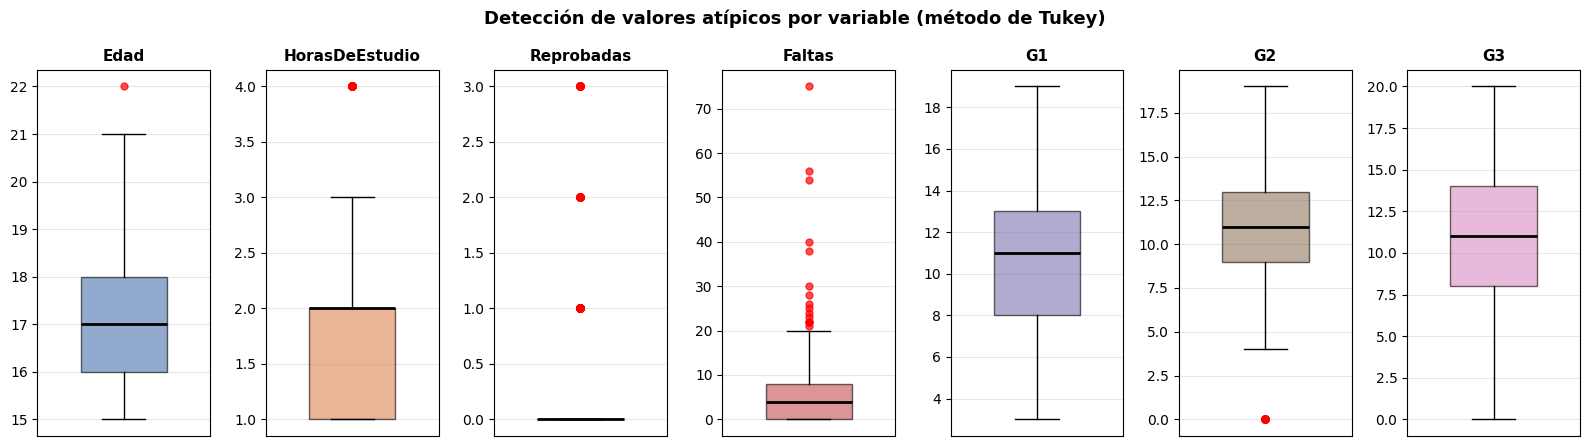

In [8]:
cols = ["Edad","HorasDeEstudio","Reprobadas","Faltas","G1","G2","G3"]
colores = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860", "#DA8BC3"]

fig, axes = plt.subplots(1, len(cols), figsize=(16,4.5))
for ax, col, color in zip(axes, cols, colores):
    ax.boxplot(df[col], patch_artist=True, widths=0.5,
               boxprops=dict(facecolor=color, alpha=0.6, edgecolor="black"),
               medianprops=dict(color="black", linewidth=2),
               flierprops=dict(marker="o", markerfacecolor="red", markeredgecolor="red", markersize=5, alpha=0.7))
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xticks([])
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Detección de valores atípicos por variable (método de Tukey)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Las outliers que se quedan
* Reprobadas(83) y Horas de Estudios(27),  En `Reprobadas`, el 75% de los estudiantes tiene 0 materias reprobadas, por lo que Q1 = Q3 = 0 y el rango intercuartílico es cero: cualquier valor distinto de 0 queda marcado como atípico, aunque 1, 2 o 3 reprobadas sean valores perfectamente válidos de la variable. Algo similar sucede con `HorasDeEstudio`, cuyo rango completo (1 a 4) es tan angosto que el límite superior de Tukey (3.5) cae dentro del rango válido de la variable. En ambos casos no se elimina ninguna observación: el problema es del método aplicado a variables acotadas y discretas, no de los datos.

* Edad, G1 y G3, no tienen muchos outliers

* Se puede ver que los valores suben de poco a poco, no es un valor de 10 que luego sube a 70, va gradualmente de 20 a 30 a 40 hasta 70, entonces vale la pena dejarlos

* Los 13 outliers no se quitan de G2


# Análisis de Relaciones entre Variables

Antes de estudiar la colinealidad entre las variables explicativas, dividimos el conjunto de datos en entrenamiento (80%) y prueba (20%), pues a partir de este punto **todo el análisis de relación entre variables y la selección de características se hará únicamente con el subconjunto de entrenamiento**, dejando el subconjunto de prueba completamente al margen hasta la evaluación final del modelo. Esta es la medida principal que se tomó en este reporte para evitar fuga de datos.

- `train_test_split` (de `sklearn.model_selection`) divide el data frame en dos subconjuntos de forma aleatoria
- `train_size=0.8` indica que el 80% de las observaciones va a `train` y el 20% restante a `test`
- `random_state=42` fija la semilla del generador aleatorio, para que la división sea siempre la misma cada vez que se corra el código (reproducibilidad)
- `train.shape` y `test.shape` confirman cuántas observaciones y columnas quedaron en cada subconjunto

In [9]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, train_size=0.8, random_state=67)
print(train.shape)
print(test.shape)

(316, 10)
(79, 10)


Quedamos con 305 observaciones de entrenamiento y 77 de prueba. Ahora sí, generamos la matriz de correlación de Pearson entre todas las variables (incluyendo `G3`, para tener una primera idea de qué variables podrían ser más relevantes) usando únicamente `train`, y la visualizamos con un *heatmap* de la librería seaborn, tal como en la lectura L1.5.

- `train.corr()` calcula la correlación de Pearson entre cada par de columnas del subconjunto de entrenamiento, regresando una matriz cuadrada de correlaciones
- `heatmap(...)` (de la librería `seaborn`) dibuja esa matriz como un mapa de calor, donde el color de cada celda representa qué tan fuerte es la correlación entre esas dos variables
- `annot=True` imprime el valor numérico de la correlación dentro de cada celda; `fmt=".2f"` lo redondea a 2 decimales
- `cmap="coolwarm"` define la paleta de colores: tonos rojos para correlaciones positivas, azules para negativas, y blanco cerca de 0
- `plt.title(...)` le pone nombre a la gráfica, y `plt.show()` la despliega

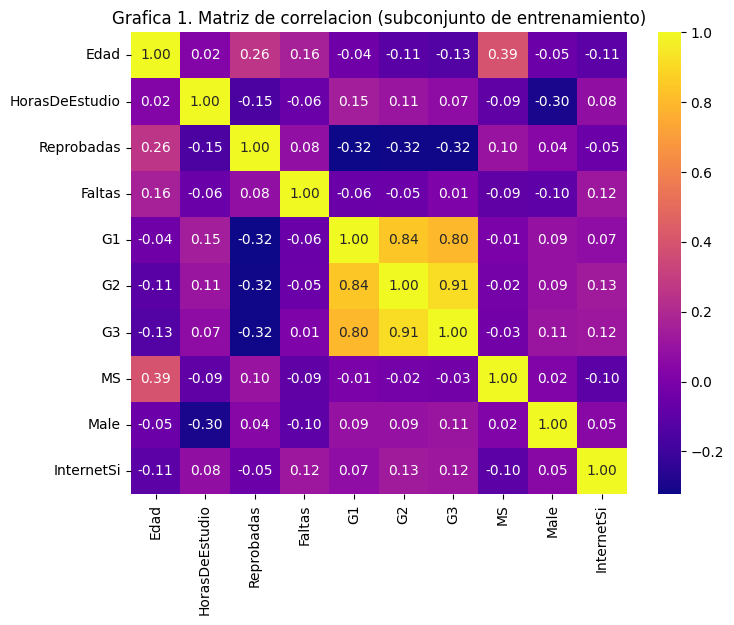

In [10]:
import matplotlib.pyplot as plt
from seaborn import heatmap

corrTrain = train.corr()
plt.figure(figsize=(8,6))
heatmap(corrTrain, annot=True, fmt=".2f", cmap="plasma")
plt.title("Grafica 1. Matriz de correlacion (subconjunto de entrenamiento)")
plt.show()

La correlación más alta entre las variables **explicativas** sigue siendo `G1`-`G2` (0.91): tiene sentido, pues ambas son calificaciones de la misma materia, medidas con pocos meses de diferencia, así que es esperable que un estudiante con buen desempeño en un periodo también lo tenga en el otro.

Las siguientes correlaciones más altas entre explicativas son `Edad`-`MS` (0.38) y `HorasDeEstudio`-`Male` (-0.30). Fuera de esas, ninguna otra pareja de variables explicativas supera 0.2 de correlación.

Con esto, no se elimina ninguna variable en esta sección: la única relación que se acerca a ser un problema de colinealidad es `G1`-`G2`, y se deja que el proceso de selección de características de la siguiente sección decida, con evidencia (R² ajustada), si conviene conservar ambas o no, en vez de decidirlo aquí a partir únicamente del valor de la correlación.

# Selección de Caracteristicas

Empezamos generando un modelo de referencia con las 9 variables explicativas disponibles (`Edad`, `HorasDeEstudio`, `Reprobadas`, `Faltas`, `G1`, `G2`, `MS`, `Male`, `InternetSi`), entrenado únicamente con el subconjunto de entrenamiento, para tener un punto de comparación contra el que evaluar si la selección de características logra simplificar el modelo sin perder desempeño.

- `X_train = train.drop(columns=["G3"])` separa las variables explicativas, quitando `G3` (que es la variable de respuesta) del subconjunto de entrenamiento
- `Y_train = train["G3"]` guarda `G3` por separado, como la variable que se quiere predecir
- `sm.add_constant(X_train)` agrega una columna de puros 1's a `X_train`, necesaria para que el modelo estime el intercepto ($\beta_0$)
- `sm.OLS(Y_train, ...)` define el modelo de regresión lineal por mínimos cuadrados ordinarios (*Ordinary Least Squares*), usando `Y_train` como respuesta
- `.fit()` entrena el modelo, estimando los coeficientes que minimizan la suma de errores al cuadrado
- `.summary()` imprime una tabla con los coeficientes, sus p-values, la R², la R² ajustada y el estadístico F del modelo completo

In [11]:
import statsmodels.api as sm

X_train = train.drop(columns=["G3"])
Y_train = train["G3"]

modelFull = sm.OLS(Y_train, sm.add_constant(X_train)).fit()
print(modelFull.summary())

                            OLS Regression Results                            
Dep. Variable:                     G3   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     173.5
Date:                Mon, 24 Aug 2026   Prob (F-statistic):          1.45e-114
Time:                        20:17:37   Log-Likelihood:                -643.63
No. Observations:                 316   AIC:                             1307.
Df Residuals:                     306   BIC:                             1345.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.9930      1.608      0.

En el modelo completo de arriba (9 variables, R² ajustada de 0.831), `G2` domina claramente (coef 0.97, p≈0) y `G1` y `Faltas` tambien resultan significativas (p<0.05), pero `Edad`, `HorasDeEstudio`, `Reprobadas`, `MS`, `Male` e `InternetSi` no lo son de forma individual (p>0.05). Ademas, los residuales del modelo no se distribuyen normal (Jarque-Bera con p practicamente cero), lo cual le resta confiabilidad a esos p-values — asi que no conviene decidir a mano, solo viendo la tabla, cuales variables quitar.

Ahora que ya vimos que el modelo completo (9 variables) tiene varias variables que no son significativas por si solas, el siguiente paso es la seleccion de caracteristicas: en vez de decidir a mano cuales quitar, vamos a rankear las variables explicativas segun que tanto se relacionan con `G3`, y usar ese orden para ir probando modelos mas chicos.

**Por que rankear primero:** con 9 variables candidatas, probar todas las combinaciones posibles (busqueda exhaustiva) seria 2^9 = 512 modelos. En vez de eso, usamos la **seleccion hacia adelante rapida**.

La version rapida fija el orden desde el inicio segun la correlacion, sin volver a evaluarlo, la cual es mas rapida, pero no garantiza encontrar el mejor subconjunto posible. Por eso, mas adelante, aplicamos ademas una eliminacion hacia atras sobre el resultado, para corregir esa debilidad.

**Como lo vamos a hacer:**
- Calculamos la correlacion de Pearson (en valor absoluto) entre cada variable explicativa y `G3`, usando solo `train`
- Ordenamos las variables de mayor a menor correlacion
- Con ese orden, entrenamos un modelo por cada cantidad de variables (1, 2, 3... hasta las 9), y guardamos la R² ajustada de cada uno
- Graficamos esos resultados para ver en que punto ya no vale la pena seguir agregando variables

- `pearsonr(X, Y)` (de `scipy.stats`) calcula la correlación de Pearson entre dos variables, y regresa una tupla donde el primer valor es el coeficiente de correlación
- `n = X_train.shape[1]` guarda cuántas variables explicativas hay (columnas de `X_train`)
- `cor = np.zeros(n)` crea un arreglo vacío donde se va a guardar la correlación de cada variable
- El ciclo `for` recorre cada columna de `X_train`, calcula su correlación con `Y_train`, y guarda el valor absoluto (`abs(...)`) en `cor` — se usa el valor absoluto porque nos interesa qué tan fuerte es la relación, sin importar si es positiva o negativa
- `np.argsort(-cor)` regresa los índices que ordenarían el arreglo `cor` de mayor a menor (el signo negativo invierte el orden ascendente por defecto de `argsort`)
- El segundo ciclo `for` imprime cada variable junto con su correlación, ya en el orden del ranking (de la más a la menos correlacionada con `G3`)

In [12]:
from scipy.stats import pearsonr

n = X_train.shape[1]
cor = np.zeros(n)
for i in range(n):
    cor[i] = abs(pearsonr(X_train.iloc[:, i], Y_train)[0])
ind = np.argsort(-cor)
for i in ind:
    print(f"{X_train.columns[i]:15s} {cor[i]:.3f}")

G2              0.908
G1              0.797
Reprobadas      0.317
Edad            0.132
InternetSi      0.120
Male            0.108
HorasDeEstudio  0.067
MS              0.028
Faltas          0.011


Aqui podemos ver que las mejores variables fueron las siguientes
- G2 y G1 con una correlacción0.908 y 0.797
- Reprobada con 0.317
- Edad InternetSi y Male entre 0.132 y 0.108

Y todas las demas con menos de .108

Ya con esto podemos hacer los modelos empezando desde G2

## Modelos con selección rapida

- `Radj = np.zeros(len(ind))` crea un arreglo vacío donde se va a guardar la R² ajustada de cada modelo, uno por cada cantidad de variables
- El ciclo `for` recorre las cantidades de variables, de 1 hasta el total (9)
- `Xtemp = X_train.iloc[:, ind[0:i+1]]` toma las primeras `i+1` variables del ranking (en el orden ya calculado)
- Se entrena un modelo (`sm.OLS(...).fit()`) usando solo esas variables
- `Radj[i] = modelTemp.rsquared_adj` guarda la R² ajustada de ese modelo en la posición correspondiente del arreglo
- Al final, `print(Radj)` muestra la R² ajustada obtenida con 1 variable, con 2, con 3... hasta con las 9 completas

[0.8245647  0.82719083 0.82727566 0.82757613 0.82702023 0.82693977
 0.82777774 0.82721676 0.83128662]


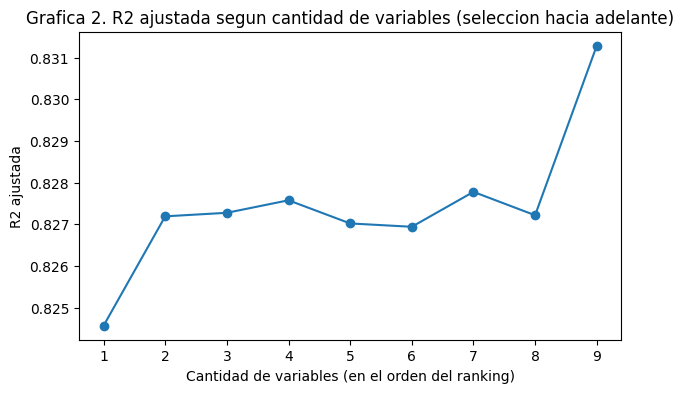

In [13]:
Radj = np.zeros(len(ind))
for i in range(len(ind)):
    Xtemp = X_train.iloc[:, ind[0:i+1]]
    modelTemp = sm.OLS(Y_train, sm.add_constant(Xtemp)).fit()
    Radj[i] = modelTemp.rsquared_adj
print(Radj)

#La graficamos
plt.figure(figsize=(7,4))
plt.plot(range(1, len(Radj)+1), Radj, "o-")
plt.xlabel("Cantidad de variables (en el orden del ranking)")
plt.ylabel("R2 ajustada")
plt.title("Grafica 2. R2 ajustada segun cantidad de variables (seleccion hacia adelante)")
plt.show()

Podemos ver que cuando se usa solo una variable, la r² ajustada es 8.25, luego entre variables 2 y 8, sube entre .827 y .828. Finalmente con 9 variables sube intensamente a .8312

Lo que sigue en los pasos de selección adelante rápida es hacer un check para atras para comparar quitando a ver si cambia si quitamos alguna variable del modelo

Tomamos el subconjunto completo de 9 variables y aplicamos eliminación hacia atrás: por cada variable, entrenamos un modelo sin ella y guardamos su R² ajustada, para ver si eliminarla mejora o empeora el desempeño respecto a tenerlas todas.

- `Xfs = X_train.iloc[:, ind[:9]]` toma las 9 variables explicativas (en este caso, todas)
- `RadjBE = np.zeros(9)` crea un arreglo vacío donde se va a guardar la R² ajustada al quitar cada variable
- El ciclo `for` recorre cada una de las 9 variables
- `Xtemp = Xfs.drop(columns=[Xfs.columns[i]])` genera un subconjunto sin la variable `i`
- Se entrena un modelo con ese subconjunto, y se guarda su R² ajustada en `RadjBE[i]`
- Al final, se imprime la R² ajustada obtenida al eliminar cada variable, junto con la R² ajustada del modelo con las 9 variables completas (`Radj[8]`), como punto de comparación
- Si al quitar alguna variable la R² ajustada **sube** respecto al modelo completo, esa variable no está aportando y conviene eliminarla

In [14]:
Xfs = X_train.iloc[:, ind[:9]]
RadjBE = np.zeros(9)
for i in range(9):
    Xtemp = Xfs.drop(columns=[Xfs.columns[i]])
    modelTemp = sm.OLS(Y_train, sm.add_constant(Xtemp)).fit()
    RadjBE[i] = modelTemp.rsquared_adj
for i in range(9):
    print(f"sin {Xfs.columns[i]:15s} -> R2 ajustada = {RadjBE[i]:.4f}")
print(f"con las 9 variables completas -> R2 ajustada = {Radj[8]:.4f}")

sin G2              -> R2 ajustada = 0.6488
sin G1              -> R2 ajustada = 0.8281
sin Reprobadas      -> R2 ajustada = 0.8312
sin Edad            -> R2 ajustada = 0.8304
sin InternetSi      -> R2 ajustada = 0.8318
sin Male            -> R2 ajustada = 0.8315
sin HorasDeEstudio  -> R2 ajustada = 0.8310
sin MS              -> R2 ajustada = 0.8317
sin Faltas          -> R2 ajustada = 0.8272
con las 9 variables completas -> R2 ajustada = 0.8313


Vamos a quitar la variable de InternetSi, como la r2 ajustada es .0005 mejor cuando no esta InternetSi. Eliminar cualquiera de las otras 8 haria que el modelo sea peor

Con InternetSi fuera, repetimos el mismo proceso de eliminación hacia atrás sobre el subconjunto restante, para confirmar si ya no se puede simplificar más.




In [15]:
# Subconjunto final de 6 variables (se elimina InternetSi)
setFinal = ["G2", "G1", "Reprobadas", "HorasDeEstudio", "Edad", "Faltas", "Male", "MS"]
df_Set_Final = X_train[setFinal]
# Repite la eliminacion hacia atras sobre las 6 variables
RadjBE8 = {}
for c in setFinal:
    Xtemp = df_Set_Final.drop(columns=[c])
    modelTemp = sm.OLS(Y_train, sm.add_constant(Xtemp)).fit()
    RadjBE8[c] = modelTemp.rsquared_adj
for c, val in RadjBE8.items():
    print(f"sin {c:15s} -> R2 ajustada = {val:.4f}")

modelFinal8 = sm.OLS(Y_train, sm.add_constant(df_Set_Final)).fit()
print(f"con las 8 variables completas -> R2 ajustada = {modelFinal8.rsquared_adj:.4f}")

sin G2              -> R2 ajustada = 0.6480
sin G1              -> R2 ajustada = 0.8285
sin Reprobadas      -> R2 ajustada = 0.8317
sin HorasDeEstudio  -> R2 ajustada = 0.8314
sin Edad            -> R2 ajustada = 0.8309
sin Faltas          -> R2 ajustada = 0.8278
sin Male            -> R2 ajustada = 0.8320
sin MS              -> R2 ajustada = 0.8322
con las 8 variables completas -> R2 ajustada = 0.8318


Vamos a quitar la variable de MS, como la r2 ajustada es .0004 mejor cuando no esta MS. Eliminar cualquiera de las otras 7 haria que el modelo sea peor

Con MS fuera, repetimos el mismo proceso de eliminación hacia atrás sobre el subconjunto restante, para confirmar si ya no se puede simplificar más.




In [16]:
# Subconjunto final de 6 variables (se elimina InternetSi)
setFinal = ["G2", "G1", "Reprobadas", "HorasDeEstudio", "Edad", "Faltas", "Male"]
df_Set_Final = X_train[setFinal]
# Repite la eliminacion hacia atras sobre las 6 variables
RadjBE8 = {}
for c in setFinal:
    Xtemp = df_Set_Final.drop(columns=[c])
    modelTemp = sm.OLS(Y_train, sm.add_constant(Xtemp)).fit()
    RadjBE8[c] = modelTemp.rsquared_adj
for c, val in RadjBE8.items():
    print(f"sin {c:15s} -> R2 ajustada = {val:.4f}")

modelFinal8 = sm.OLS(Y_train, sm.add_constant(df_Set_Final)).fit()
print(f"con las 7 variables completas -> R2 ajustada = {modelFinal8.rsquared_adj:.4f}")

sin G2              -> R2 ajustada = 0.6485
sin G1              -> R2 ajustada = 0.8289
sin Reprobadas      -> R2 ajustada = 0.8321
sin HorasDeEstudio  -> R2 ajustada = 0.8317
sin Edad            -> R2 ajustada = 0.8314
sin Faltas          -> R2 ajustada = 0.8283
sin Male            -> R2 ajustada = 0.8324
con las 7 variables completas -> R2 ajustada = 0.8322


Vamos a quitar la variable de Male, como la r2 ajustada es .0002 mejor cuando no esta Male. Eliminar cualquiera de las otras 6 haria que el modelo sea peor

Con Male fuera, repetimos el mismo proceso de eliminación hacia atrás sobre el subconjunto restante, para confirmar si ya no se puede simplificar más.




In [17]:
# Subconjunto final de 6 variables (se elimina InternetSi)
setFinal = ["G2", "G1", "Reprobadas", "HorasDeEstudio", "Edad", "Faltas"]
df_Set_Final = X_train[setFinal]
# Repite la eliminacion hacia atras sobre las 6 variables
RadjBE8 = {}
for c in setFinal:
    Xtemp = df_Set_Final.drop(columns=[c])
    modelTemp = sm.OLS(Y_train, sm.add_constant(Xtemp)).fit()
    RadjBE8[c] = modelTemp.rsquared_adj
for c, val in RadjBE8.items():
    print(f"sin {c:15s} -> R2 ajustada = {val:.4f}")

modelFinal8 = sm.OLS(Y_train, sm.add_constant(df_Set_Final)).fit()
print(f"con las 6 variables completas -> R2 ajustada = {modelFinal8.rsquared_adj:.4f}")

sin G2              -> R2 ajustada = 0.6490
sin G1              -> R2 ajustada = 0.8290
sin Reprobadas      -> R2 ajustada = 0.8324
sin HorasDeEstudio  -> R2 ajustada = 0.8315
sin Edad            -> R2 ajustada = 0.8317
sin Faltas          -> R2 ajustada = 0.8288
con las 6 variables completas -> R2 ajustada = 0.8324


Ninguna eliminación mejora la R² ajustada respecto al modelo completo (0.8324): quitar Reprobadas da exactamente el mismo valor (0.8324), y quitar cualquier otra variable la empeora. Esto confirma que ya no se puede simplificar más el modelo sin perder desempeño, así que este subconjunto queda como el modelo final.

Tabla 2. Variables seleccionadas para el modelo final

| Variable | Descripción | Correlación con G3 (train) |
|---|---|---|
| G2 | Calificación del segundo periodo | 0.908 |
| G1 | Calificación del primer periodo | 0.797 |
| Reprobadas | Materias reprobadas previamente | 0.317 |
| HorasDeEstudio | Horas semanales de estudio (ordinal 1-4) | 0.067 |
| Edad | Edad del estudiante | 0.132 |
| Faltas | Faltas registradas en el curso | 0.011 |


Al hacer todas estos pasos, de ordenar variables, luego ir mejorando eliminando una por una variable. Este es el mejor modelo que podriamos obtener, entonces ahora si vamos a entrenar y evaluar el modelo con estas 6 variables.

Pudimos mejorar el modelo inicial de 0.8313 a 0.8324.

#Entrenamiento y Evaluación del Modelo

Ya finalmente podemos evaluar el modelo con las 6 variables que seleccionamos  solo con el subconjunto de entrenamiento (esto ya se hizo en la celda anterior, guardado en `modelFinal8`, pero lo volvemos a imprimir aquí como el modelo definitivo del reporte).

In [18]:
print(modelFinal8.summary())

                            OLS Regression Results                            
Dep. Variable:                     G3   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     261.8
Date:                Mon, 24 Aug 2026   Prob (F-statistic):          5.89e-118
Time:                        20:17:38   Log-Likelihood:                -644.08
No. Observations:                 316   AIC:                             1302.
Df Residuals:                     309   BIC:                             1328.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.7481      1.456      0.

Podemos ver que la R Cuadrada Ajustada es de 0.832, que nos dice que si es un modelo estadistico bueno, ya que nos explica el porque de el 83.2% porciento de la variabilidad de los datos

 - `G2` sigue siendo, por mucho, la variable más influyente (coeficiente de 0.97: por cada punto adicional en la calificación del segundo periodo, se espera que la calificación final suba 0.97 puntos, manteniendo el resto de las variables sin cambio).

 - `G1` también tiene un efecto positivo y significativo (p = 0.007).

 - `Faltas` tiene un coeficiente positivo y significativo (p = 0.006): más faltas se asocian con una calificación *más alta*, lo cual no era el resultado esperado.

 Reprobadas, Horas de estudio y edad tienen el signo esperado (negativo: más materias reprobadas, menos horas de estudio o más edad se asocian con calificaciones más bajas) pero no son individualmente significativas al 5%; aun así se conservan, porque su inclusión mejora la R² ajustada, como se determinó en la sección anterior.

  Ahora vamos a ver como se compara el train con el test para poder evaluar de manera correcta

In [19]:
# Genera X y Y para el subconjunto de prueba, usando las mismas 6 variables
X_test = test[setFinal]
Y_test = test["G3"]

# Predicciones y metricas en entrenamiento
Yhat_train = modelFinal8.predict(sm.add_constant(df_Set_Final))
RSS_train = sum((Y_train - Yhat_train)**2)
RSE_train = np.sqrt(RSS_train / (len(Y_train) - 7))
R2_train = modelFinal8.rsquared

# Predicciones y metricas en prueba
Yhat_test = modelFinal8.predict(sm.add_constant(X_test))
RSS_test = sum((Y_test - Yhat_test)**2)
TSS_test = sum((Y_test - Y_test.mean())**2)
RSE_test = np.sqrt(RSS_test / (len(Y_test) - 7))
R2_test = 1 - RSS_test/TSS_test

print(f"Entrenamiento -> RSE = {RSE_train:.3f}, R2 = {R2_train:.3f}")
print(f"Prueba        -> RSE = {RSE_test:.3f}, R2 = {R2_test:.3f}")

Entrenamiento -> RSE = 1.879, R2 = 0.836
Prueba        -> RSE = 2.088, R2 = 0.802


El desempeño en prueba (RSE = 2.088, R² = 0.802) es un poco peor que en entrenamiento (RSE = 1.879, R² = 0.836), pero la diferencia es no es tanta ya que el R² baja apenas 4 puntos porcentuales, y el modelo sigue explicando más del 80% de la variabilidad de `G3` en datos que nunca vio durante el entrenamiento. Esto confirma que el modelo generaliza bien, y que la selección de características fue correcta y los variables no pudieron haberse escogido de una mejor manera

Si hay diferencia, pero esto puede ser por los estudiante que se dieron de baja en el segundo semestre, que tienen una calificación de 0 en el segundo y tercer parcial

Ahora vamos a verlo de manera graficada usando plt.scatter

plt.scatter grafica cada estudiante de prueba como un punto, con su calificación real en el eje horizontal y la calificación predicha por el modelo en el eje vertical. La línea roja diagonal representa una predicción perfecta, es decir, los puntos donde el valor predicho coincide exactamente con el

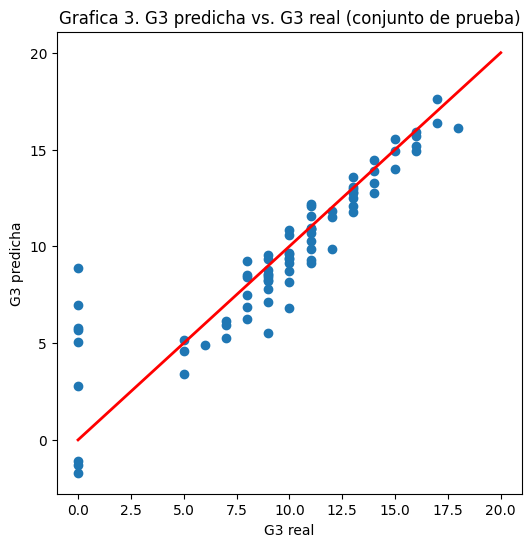

In [20]:
plt.figure(figsize=(6,6))
plt.scatter(Y_test, Yhat_test)
plt.plot([0, 20], [0, 20], c="r", linewidth=2)
plt.xlabel("G3 real")
plt.ylabel("G3 predicha")
plt.title("Grafica 3. G3 predicha vs. G3 real (conjunto de prueba)")
plt.show()

Como podemos ver el G3 predicho contra el real esta mayormente igual en la tabla

Las unicas diferencias son probablemente las personas que se dieron de baja una regresión no las puede excluir, por eso se sesgan. Intente quitarle esas personas en la exploración de datos, pero el r ajustado solo bajaba. Entonces este es el mejor modelo y esta tabla si explica de la mejor manera la correlación.

# Reflexión y Conclusiones

El objetivo de este reporte era construir un modelo de regresión lineal múltiple para predecir la calificación final de un estudiante, enfrentando de forma explícita los retos de un conjunto de datos parecidos a casos reales. Al final es un modelo con las 6 variables(G2, G1, Reprobadas, HorasDeEstudio, Edad, Faltas) que explica el 83.2% de la variabilidad de G3 en entrenamiento, y el 80.2% en un conjunto de prueba que el modelo nunca vio. Esto lo hace un modelo bastante solido

Un punto importante que vale la pena dejar documentado es una decisión que se tomó y luego se revirtió: en un momento del análisis se intentó eliminar a los estudiantes con calificaciones de G2 en cero, bajo el argumento de que probablemente representan abandono del curso y no un desempeño académico bajo, y que mezclar ambos fenómenos en la misma variable de respuesta podría sesgar al modelo. Al hacer esa prueba, la R² ajustada bajó de forma notable (de 0.83 a cerca de 0.78), no porque el modelo se volviera peor prediciendo, sino porque quitar esos casos extremos también reduce mucho la varianza total que había que explicar (TSS), y R² es una medida relativa a esa varianza. Sabiendo todo esto, se decidio dejar las variables de los estudiantes que se salieron del curso, aunque el train y test tengan un poco de diferencia, es mejor eso a que baje el R2 a .78

Aqui podemos concluir que la preparación de los datos sí importa, aunque tenemos que tomar en cuenta que si dejamos una variable para probar modelos con el metodo rápido, eso no significa que no la vamos a eliminar despues. Ya que aunque pensemos que si importa, si hay algun modelo mejor sin incluir esa variable, es mejor eliminarlo


La brecha entre el desempeño en entrenamiento y en prueba (RSE de 1.88 a 2.09) es moderada, no dramática, lo cual respalda que la selección de características, hecha únicamente con el subconjunto de entrenamiento, no incurrió en fuga de datos.

### Limitaciones

- El modelo aun tiene a estudiantes que abandonaron el curso, estaría bien conseguir más datos no sesgados sin estudiantes que dejaron el curso
- El modelo depende fuertemente de G2 y G1; predecir G3 sin las calificaciones parciales sería mucho más difícil, pero también mucho más útil en la práctica, por ejemplo para identificar a un estudiante en riesgo antes de que existan calificaciones parciales bajas.
- Al ser un modelo lineal, no puede capturar bien el comportamiento de "todo o nada" de los estudiantes que abandonan, que son precisamente los casos con mayor error de predicción tanto en entrenamiento como en prueba.
- Este reporte usa solo 10 de las 33 variables originales del dataset original

### Trabajo futuro

- Entrenar un modelo de clasificación (por ejemplo, regresión logística) para predecir por separado si un estudiante va a abandonar el curso, y combinarlo con un modelo de regresión como el de este reporte para los estudiantes que sí lo completan, en vez de intentar resolver ambos problemas con una sola recta.